In a backward pass, PyTorch would usually pass the gradients from all neurons of a higher layer to the lower layers and mix them up, however CRP works by passing only specific parts of the gradients and zeroing out the others. Zennit replaces these gradients with actual attribution scores that flow from the last layer to the first one.

In the Image **a)** you see, that we only pass the attributions of the neuron '0' in layer 'layer3' to the next layers. And then again pass only the attributions of neuron '0' and '2' in layer 'layer1' to the input.
If we were to implement this with a normal PyTorch [backward hook](https://pytorch.org/docs/stable/generated/torch.nn.modules.module.register_module_full_backward_hook.html) in layer 'layer1', we would write the following code that sets the input gradient to zero everywhere except for the neurons '0' and '2':

In [1]:
%cd ..
%ls

/home/satou/Projects/crp-experimenting
cache/                        relevance_lrp.npy
CLAUDE_CONTEXT.md             relevance_resnet_crp.npy
conf/                         relevance_resnet_lrp.npy
data/                         relevance_vit_crp_no_composite.npy
display_heatmap.ipynb         relevance_vit_crp.npy
download_defected_vit.py      relevance_vit_crp_visualization.png
gpg.sh                        relevance_vit_lrp.npy
ImageNet_data/                src/
imagenet_output/              state_dict_version1_tl_best.pth
LICENSE                       tests/
one_layer_cnn_weights.pth     test_simple.ipynb
one_layer_linear_weights.pth  TRANSFORMER_NOTEBOOK_SUMMARY.md
__pycache__/                  tutorials/
pyproject.toml                USE_POLICY
README.md                     uv.lock
relevance_big_conv_crp.npy    VGG16_ImageNet/
relevance_big_conv_lrp.npy    VIT_B16_ImageNet/
relevance_conv_lrp.npy


In [5]:
import itertools

import torch
import zennit.rules as z_rules
from IPython.display import Image as DisplayImage
from IPython.display import display

from PIL import Image
from torchvision.models import vision_transformer
from zennit.composites import LayerMapComposite
from zennit.image import imgify

from crp.attribution import CondAttribution
from crp.concepts import ChannelConcept
from crp.transformer_patches import monkey_patch, monkey_patch_zennit

In [6]:

# Check for GPU, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [9]:
# 1. Monkey Patch FIRST (This makes the model "Attention-Aware")
monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)


# 2. Load Model (Standard PyTorch)
def get_vit_imagenet(device="cuda"):
    weights = vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval().to(device)
    for param in model.parameters():
        param.requires_grad = False
    return model, weights


if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this comparison; no GPU detected.")
device = "cuda"
model, weights = get_vit_imagenet(device)

# 3. Load Image
image = Image.open("tutorials/images/lizard.jpg").convert("RGB")
data = weights.transforms()(image).unsqueeze(0).to(device)
data.requires_grad = True

RuntimeError: CUDA is required for this comparison; no GPU detected.

In [4]:
composite = LayerMapComposite(
    [
        (torch.nn.Conv2d, z_rules.Gamma(0.25)),
        (torch.nn.Linear, z_rules.Gamma(0.1)),
    ]
)

# Define the Concept (The Query)
# ChannelConcept allows us to mask specific channels if we want.
cc = ChannelConcept()

# Initialize the Attributor (The Engine)
# This engine will drive the backward pass.
attributor = CondAttribution(model)

In [5]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

The `mask` method of the `ChannelConcept` class returns a function similar to the previous mask_hook function.
`ChannelConcept.mask` allows to mask individual channels as well as MLP neurons per batch.

In [ ]:
# 1. Define the LXT-style modifier function
def chanel_wise_heatmap_modifier(self, data, on_device=None):
    """Computes Relevance = Input * Gradient.
    Does NOT sum over channels (dim 1), preserving RGB info.
    """
    # Get the gradient
    grad = data.grad.detach()

    # Handle device transfer if requested
    if on_device:
        grad = grad.to(on_device)
        data_fixed = data.detach().to(on_device)
    else:
        data_fixed = data.detach()

    relevance = data_fixed * grad

    # Return 4D tensor: (Batch, Channels, Height, Width)
    return relevance


# 2. Monkey Patch your specific instance
# This replaces the 'heatmap_modifier' method ONLY for this 'attributor' object.

In [7]:
prediction = model(data)
target_class = prediction.argmax().item()
print(f"Explaining class: {target_class}")

conditions = [{"y": target_class}]

# ... Run attribution with masking disabled to mirror LRP ...
attr = attributor(data, conditions, composite, mask_map=None)

# 1. Extract the result (It is now RGB!)
# Shape: (1, 3, 224, 224)
rgb_relevance = attr.heatmap[0].detach().cpu()

# 2. Sum channels YOURSELF for visualization (Grayscale)
# Shape: (224, 224)
grayscale_relevance = rgb_relevance.sum(0)
grayscale_relevance = grayscale_relevance / grayscale_relevance.abs().max()

# 3. Save
imgify(grayscale_relevance.unsqueeze(0), symmetric=True, grid=(1, 1)).save(
    "out/lxt_style_result.png"
)

Explaining class: 40


/home/jovyan/RationAI/projectCRP/crp-experimenting/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [13]:
composite = LayerMapComposite(
    [
        (torch.nn.Conv2d, z_rules.Gamma(0.25)),
        (torch.nn.Linear, z_rules.Gamma(0.1)),
        #     (torch.nn.LayerNorm, z_rules.Pass()),
    ]
)

prediction = model(data)
target_class = prediction.argmax().item()
print(f"Explaining class: {target_class}")

conditions = [{"y": target_class}]

# Run Attribution with masking disabled for LRP equivalence
attr = attributor(data, conditions, composite, mask_map=None)

# Convert to grayscale and normalize
heatmap_crp = attr.heatmap.sum(1)
heatmap_crp = heatmap_crp / heatmap_crp.abs().max()

imgify(heatmap_crp.detach().cpu(), symmetric=True, grid=(1, 1)).save(
    "out/vit_crp_heatmap_norm.png"
)

Explaining class: 40


OSError: [Errno 28] No space left on device

In [9]:
lrp_blob = torch.load("LRP-eXplains-Transformers/examples/vit_lrp_heatmap_lizard.pt")
lrp_heatmap = lrp_blob["heatmap"].to(heatmap_crp.device)
lrp_class_idx = lrp_blob.get("class_idx", None)
print(f"LRP saved class idx: {lrp_class_idx}")

LRP saved class idx: 40


In [12]:
# Token-level gradient heatmap from encoder block output (includes CLS-patch interactions)
# Falls back to the second-last block if the last block gives (near) zero gradients.


def _capture_block_and_grad(block, label):
    captured = {}

    def _hook(_, __, out):
        captured["out"] = out

    handle = block.register_forward_hook(_hook)
    pred = model(data.requires_grad_())
    handle.remove()
    if "out" not in captured:
        raise RuntimeError(f"Did not capture output for {label}")
    out = captured["out"]
    print(f"Captured '{label}' output shape: {tuple(out.shape)}")
    target_logit = pred[0, target_class]
    grad = torch.autograd.grad(
        target_logit, out, allow_unused=False, retain_graph=True
    )[0]
    if grad is None:
        raise RuntimeError(f"Gradient wrt '{label}' is None")
    print(
        f"Gradient wrt '{label}' shape: {tuple(grad.shape)}, max={grad.abs().max().item():.3e}"
    )
    return grad


# Try last block output first
layer_label = "encoder.layers[-1]"
last_block = model.encoder.layers[-1]
grad_single = _capture_block_and_grad(last_block, layer_label)

# If nearly zero, fall back to second-last block
if grad_single.abs().max() < 1e-8 and len(model.encoder.layers) > 1:
    layer_label = "encoder.layers[-2]"
    snd_block = model.encoder.layers[-2]
    grad_single = _capture_block_and_grad(snd_block, layer_label)

# Build token heatmap
if grad_single.dim() == 3:
    heatmap_single = grad_single.sum(2)
    # Remove CLS token if present
    if heatmap_single.size(1) == 197:
        heatmap_single = heatmap_single[:, 1:]
    elif heatmap_single.size(1) == 196:
        pass
    else:
        raise RuntimeError(
            f"Unexpected token count: {heatmap_single.size(1)}. Expected 196 or 197."
        )
    h = w = int(heatmap_single.size(1) ** 0.5)
    if h * w != heatmap_single.size(1):
        raise RuntimeError(
            f"Cannot reshape to square grid: {heatmap_single.size(1)} tokens."
        )
    heatmap_single = heatmap_single.reshape(-1, h, w)
elif grad_single.dim() == 2:
    raise RuntimeError(
        "Got only 2D gradient (batch, 768). Hook an earlier layer that feeds CLS via attention."
    )
else:
    raise RuntimeError(f"Unexpected grad shape: {grad_single.shape}")

# Safe normalization
eps = 1e-6
denom = heatmap_single.abs().max()
heatmap_single = heatmap_single / (denom + eps)

torch.save(
    {
        "heatmap": heatmap_single.detach().cpu(),
        "layer": layer_label,
        "class_idx": target_class,
    },
    "out/vit_crp_heatmap_tokens.pt",
)

imgify(heatmap_single.unsqueeze(1).detach().cpu(), symmetric=True, grid=(1, 1)).save(
    "out/vit_crp_heatmap_tokens.png"
)

Captured 'encoder.layers[-1]' output shape: (1, 197, 768)
Gradient wrt 'encoder.layers[-1]' shape: (1, 197, 768), max=1.536e-01


/home/jovyan/RationAI/projectCRP/crp-experimenting/.venv/lib/python3.11/site-packages/zennit/image.py:184: RuntimeWarning: invalid value encountered in divide
  array = (array - vmin) / (vmax - vmin)


In [10]:
# Check raw heatmaps before normalization
print("=== LRP Heatmap Stats ===")
print(f"Min: {lrp_heatmap.min().item():.6e}, Max: {lrp_heatmap.max().item():.6e}")
print(f"Mean: {lrp_heatmap.mean().item():.6e}, Std: {lrp_heatmap.std().item():.6e}")
print(f"Sum positive: {lrp_heatmap[lrp_heatmap > 0].sum().item():.6e}")
print(f"Sum negative: {lrp_heatmap[lrp_heatmap < 0].sum().item():.6e}")

print("\n=== CRP Heatmap Stats ===")
print(f"Min: {heatmap_crp.min().item():.6e}, Max: {heatmap_crp.max().item():.6e}")
print(f"Mean: {heatmap_crp.mean().item():.6e}, Std: {heatmap_crp.std().item():.6e}")
print(f"Sum positive: {heatmap_crp[heatmap_crp > 0].sum().item():.6e}")
print(f"Sum negative: {heatmap_crp[heatmap_crp < 0].sum().item():.6e}")

print("\n=== Difference Stats ===")
diff = heatmap_crp - lrp_heatmap
print(f"Diff min: {diff.min().item():.6e}, Diff max: {diff.max().item():.6e}")
print(f"Diff mean: {diff.mean().item():.6e}")
print(f"Sign flips: {((lrp_heatmap > 0) != (heatmap_crp > 0)).sum().item()}")

=== LRP Heatmap Stats ===
Min: -2.623391e-01, Max: 1.000000e+00
Mean: 6.797127e-03, Std: 3.625463e-02
Sum positive: 4.355486e+02
Sum negative: -9.449594e+01

=== CRP Heatmap Stats ===
Min: -2.623719e-01, Max: 1.000000e+00
Mean: 6.796439e-03, Std: 3.625156e-02
Sum positive: 4.355063e+02
Sum negative: -9.448820e+01

=== Difference Stats ===
Diff min: -2.132654e-04, Diff max: 1.389161e-04
Diff mean: -6.881504e-07
Sign flips: 2


In [11]:
diff_map_crp = heatmap_crp - lrp_heatmap

print(f"max diff (crp vs lrp): {diff_map_crp.abs().max().item():.6e}")
print(f"mean diff (crp vs lrp): {diff_map_crp.abs().mean().item():.6e}")
if lrp_class_idx is not None:
    print(f"LRP heatmap class idx: {lrp_class_idx}")
    print(f"CRP heatmap class idx: {target_class}")

imgify(diff_map_crp.detach().cpu(), symmetric=True, grid=(1, 1)).save(
    "out/diff_map_crp.png"
)

max diff (crp vs lrp): 2.132654e-04
mean diff (crp vs lrp): 2.620548e-06
LRP heatmap class idx: 40
CRP heatmap class idx: 40


<built-in method type of Tensor object at 0x718f1c4f9df0>


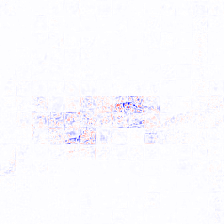

In [12]:
print(diff_map_crp.type)
imgify(diff_map_crp.detach().cpu(), symmetric=True, grid=(1, 1))

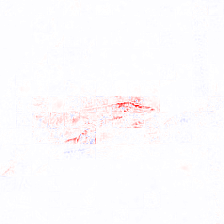

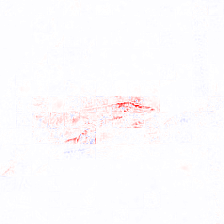

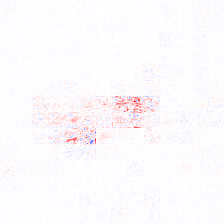

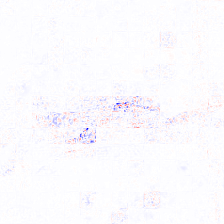

In [23]:
display(DisplayImage("out/lxt_style_result.png"))

display(DisplayImage("out/vit_crp_heatmap_pass_norm.png"))

display(DisplayImage("out/diff_map.png"))
display(DisplayImage("out/diff_map_crp.png"))

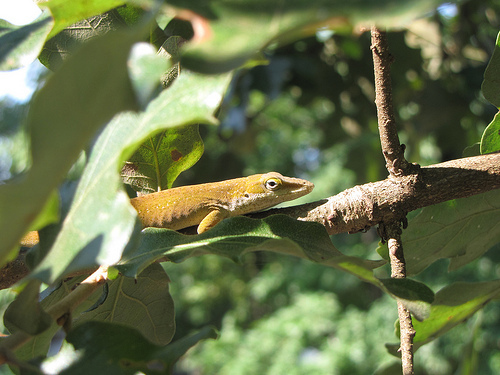

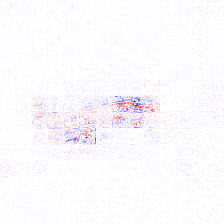

In [24]:
display(image)
display(DisplayImage("out/vit_crp_heatmap.png"))

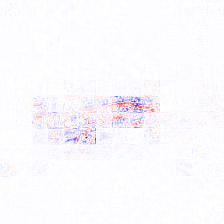

In [11]:
display(DisplayImage("vit_crp_heatmap.png"))

In [ ]:
model, weights = get_vit_imagenet()

cc = ChannelConcept()
attributor = CondAttribution(model)

prediction = model(data)
# target_class = prediction.argmax().item()
classes = torch.topk(prediction, 5)
# the best class
target_class = classes.indices[0, 0].item()
# the second best calss
# target_class = classes.indices[0, 1].item()
# the fifth best calss
# target_class = classes.indices[0, 4].item()

class_name = weights.meta["categories"][target_class]

print(f"Explaining class: {target_class} ('{class_name}')")
conditions = [{"y": target_class}]

heatmap_list = []

for conv_gamma, lin_gamma in itertools.product(
    [0.1, 0.25, 100], [0, 0.01, 0.05, 0.1, 1]
):
    composite = LayerMapComposite(
        [
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ]
    )

    # Run Attribution
    attr = attributor(data, conditions, composite, mask_map=cc.mask)

    heatmap_list.append(attr.heatmap.detach().cpu())

# Join
# Result shape: (15, 1, 3, 224, 224)
stacked_heatmaps = torch.stack(heatmap_list)

# Fix Dimensions if necessary
if stacked_heatmaps.ndim == 5:
    stacked_heatmaps = stacked_heatmaps.squeeze(1)

# Convert to Grayscale
final_tensor = stacked_heatmaps.sum(1)

print(f"Final tensor shape: {final_tensor.shape}")
imgify(final_tensor, symmetric=True, grid=(3, 5)).save(
    "out/vit_crp_heatmap_chameleon.png"
)

Explaining class: 40 ('American chameleon')
Final tensor shape: torch.Size([15, 224, 224])


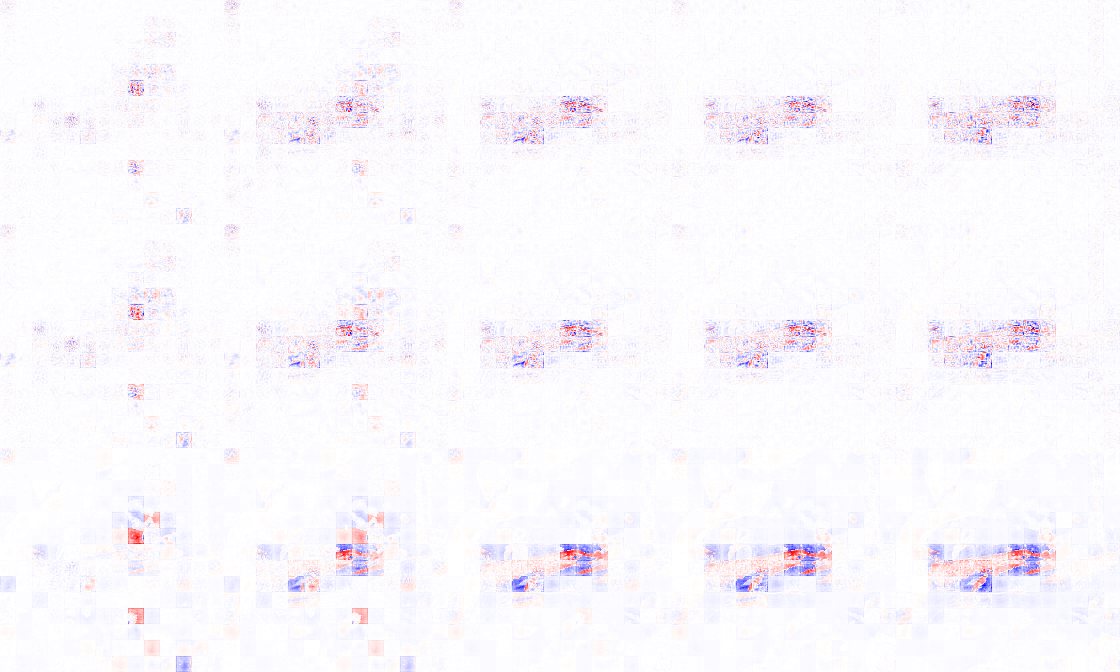

In [ ]:
display(DisplayImage("vit_crp_heatmap_lizard.png"))

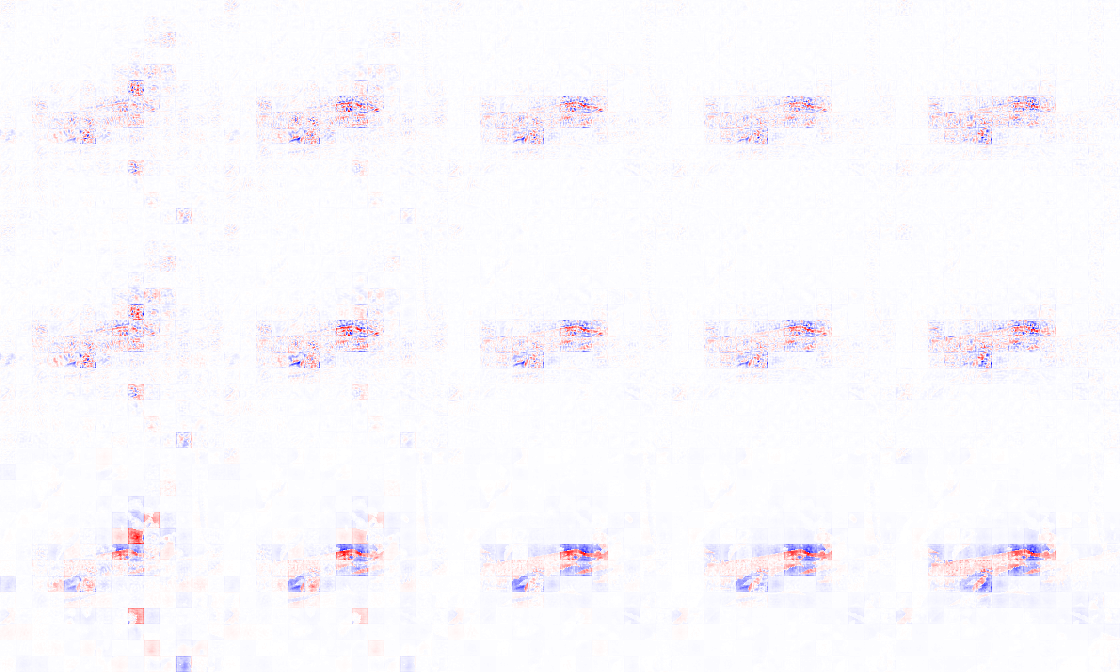

In [69]:
display(DisplayImage("vit_crp_heatmap_chameleon.png"))

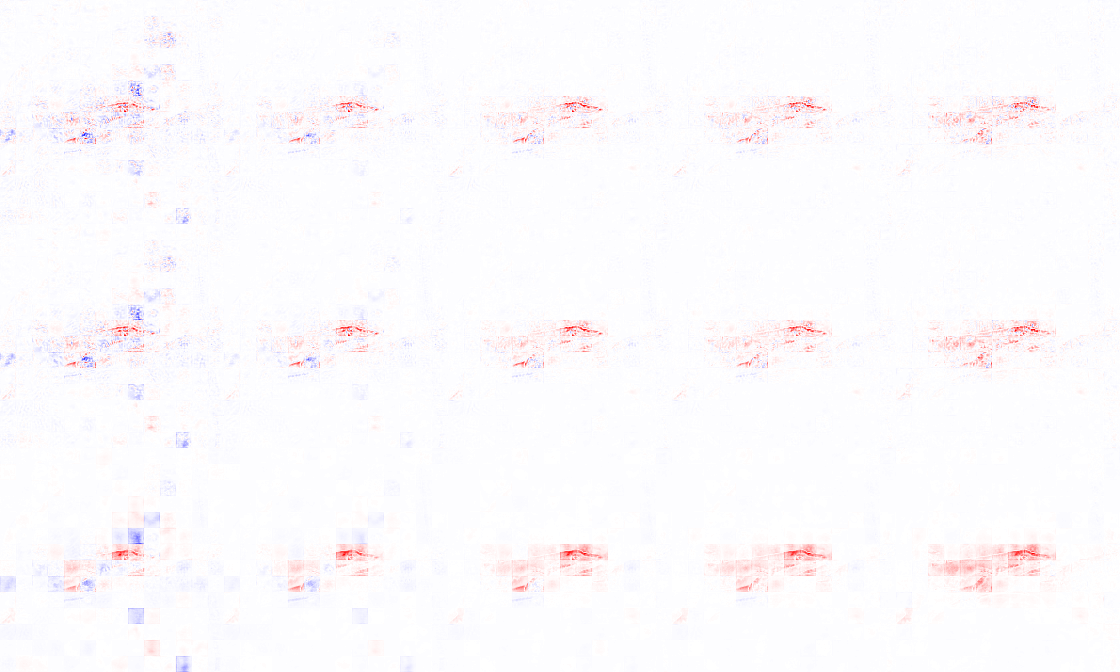

In [18]:
display(DisplayImage("vit_lrp_heatmap_chameleon.png"))

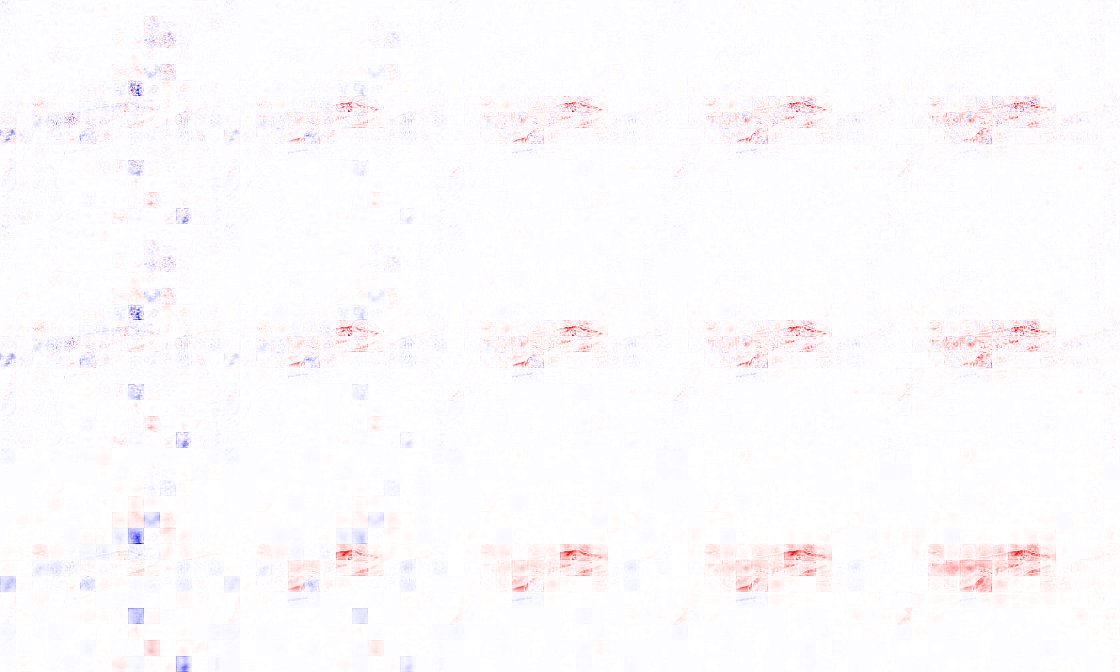

In [ ]:
display(DisplayImage("vit_crp_heatmap_chameleon_00.png"))

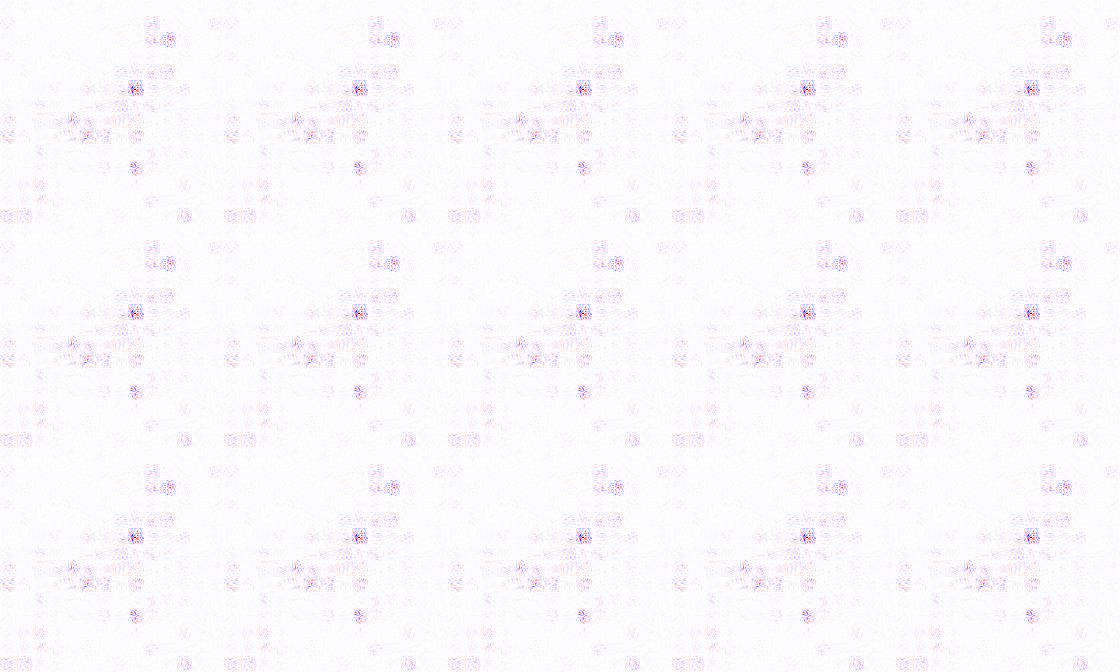

In [48]:
display(DisplayImage("vit_crp_heatmap_chameleon_00.png"))

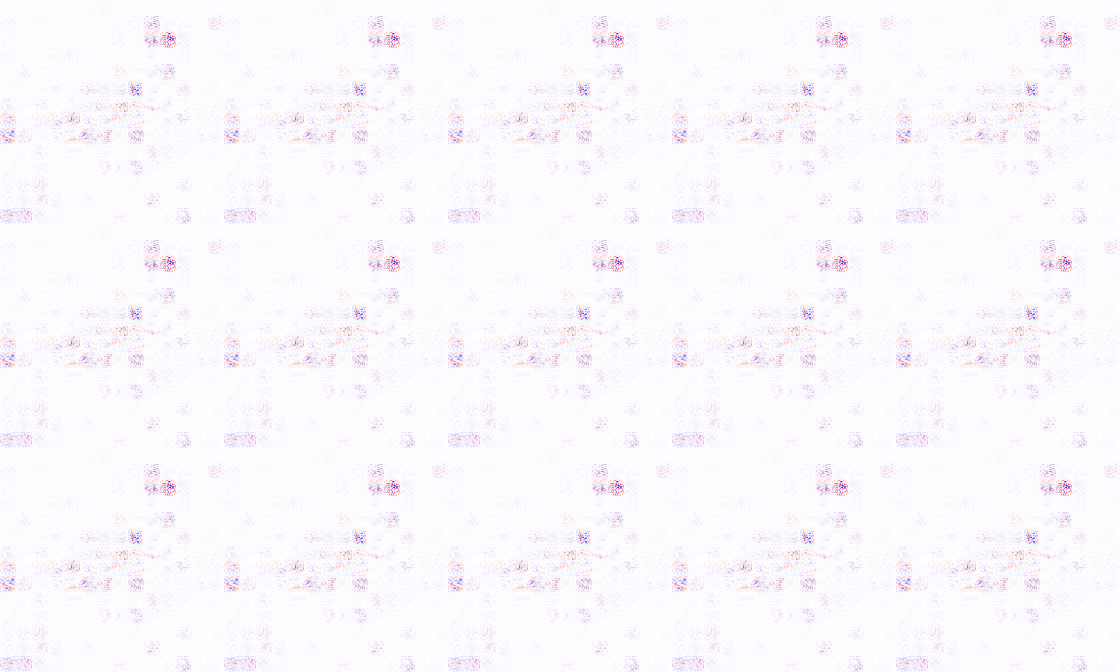

In [33]:
display(DisplayImage("vit_lrp_heatmap_chameleon_00.png"))